## 1 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix

np.random.seed(42)


## 2 · Load & Explore the Dataset


In [2]:
df_raw = pd.read_csv("/content/dataset.csv")
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Null counts per column:")
print(df_raw.isnull().sum())
print(f"\nDisease classes : {df_raw['Disease'].nunique()}")
print(f"Symptom columns : {[c for c in df_raw.columns if c.startswith('Symptom_')]}")

Null counts per column:
Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

Disease classes : 41
Symptom columns : ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']


In [4]:
print("Disease value counts:")
print(df_raw['Disease'].value_counts())

Disease value counts:
Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                   

## 3 · Preprocessing


In [5]:
df = df_raw.copy()

symptom_cols = [c for c in df.columns if c.startswith("Symptom_")]
print("Symptom columns:", symptom_cols)

for col in symptom_cols + ["Disease"]:
    df[col] = df[col].astype(str).str.strip()

df[symptom_cols] = df[symptom_cols].replace("nan", np.nan)
df[symptom_cols] = df[symptom_cols].fillna("__none__")

print("\nNull counts after cleaning:")
print(df[symptom_cols].isnull().sum())

Symptom columns: ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Null counts after cleaning:
Symptom_1     0
Symptom_2     0
Symptom_3     0
Symptom_4     0
Symptom_5     0
Symptom_6     0
Symptom_7     0
Symptom_8     0
Symptom_9     0
Symptom_10    0
Symptom_11    0
Symptom_12    0
Symptom_13    0
Symptom_14    0
Symptom_15    0
Symptom_16    0
Symptom_17    0
dtype: int64


In [6]:
# Encode target label
le = LabelEncoder()
df["Disease_enc"] = le.fit_transform(df["Disease"])
n_classes = df["Disease_enc"].nunique()
print(f"Number of disease classes: {n_classes}")


Number of disease classes: 41
Sample mapping: {'(vertigo) Paroymsal  Positional Vertigo': 0, 'AIDS': 1, 'Acne': 2, 'Alcoholic hepatitis': 3, 'Allergy': 4}


In [7]:
# 5. Build binary symptom-presence matrix
#
#  Melt all symptom columns into (row_index, symptom) pairs,
#  drop the '__none__' filler, then pivot → binary matrix.
df["_idx"] = df.index
long = (df[["_idx", "Disease_enc"] + symptom_cols]
        .melt(id_vars=["_idx", "Disease_enc"],
              value_vars=symptom_cols,
              value_name="symptom")
        .query("symptom != '__none__'")
        .copy())

long["symptom"] = long["symptom"].str.strip()

binary = (long
          .groupby(["_idx", "symptom"])
          .size()
          .unstack(fill_value=0)
          .clip(upper=1))          # presence (0/1), not count

binary = binary.join(df.set_index("_idx")[["Disease_enc"]])

print(f"Binary feature matrix shape : {binary.drop('Disease_enc',axis=1).shape}")
print(f"Unique symptoms (features)  : {binary.shape[1] - 1}")
binary.head()

Binary feature matrix shape : (4920, 131)
Unique symptoms (features)  : 131


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,Disease_enc
_idx,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15


In [8]:
# ── 6. Final X / y arrays ─────────────────────────────────────────────────────
X_all = binary.drop("Disease_enc", axis=1).values.astype(float)
y_all = binary["Disease_enc"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Classes : {n_classes}   Features : {X_train.shape[1]}")

X_train : (3936, 131)   y_train : (3936,)
X_test  : (984, 131)    y_test  : (984,)
Classes : 41   Features : 131


## 4 · K-Means Clustering 

K-Means groups data into *k* clusters by iteratively:
1. Assigning each point to its nearest centroid
2. Recomputing centroids as the mean of assigned points

We run the **Elbow Method** to find the best *k*, then evaluate with **cluster purity**  
(what fraction of points in each cluster share the majority class).



In [9]:
def initialise_centroids(X, k, seed=42):
    np.random.seed(seed)
    indices = np.random.choice(X.shape[0], size=k, replace=False)
    return X[indices].copy()

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k, old_centroids):
    new_centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        pts = X[labels == i]
        new_centroids[i] = pts.mean(axis=0) if len(pts) > 0 else old_centroids[i]
    return new_centroids

def kmeans(X, k, max_iters=100, seed=42):
    centroids = initialise_centroids(X, k, seed)
    for iteration in range(max_iters):
        labels      = assign_clusters(X, centroids)
        new_cents   = update_centroids(X, labels, k, centroids)
        if np.allclose(centroids, new_cents):
            break
        centroids = new_cents
    dist_matrix       = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    assigned_dist     = dist_matrix[np.arange(len(X)), labels]
    inertia           = np.sum(assigned_dist ** 2)
    return labels, centroids, inertia, iteration + 1


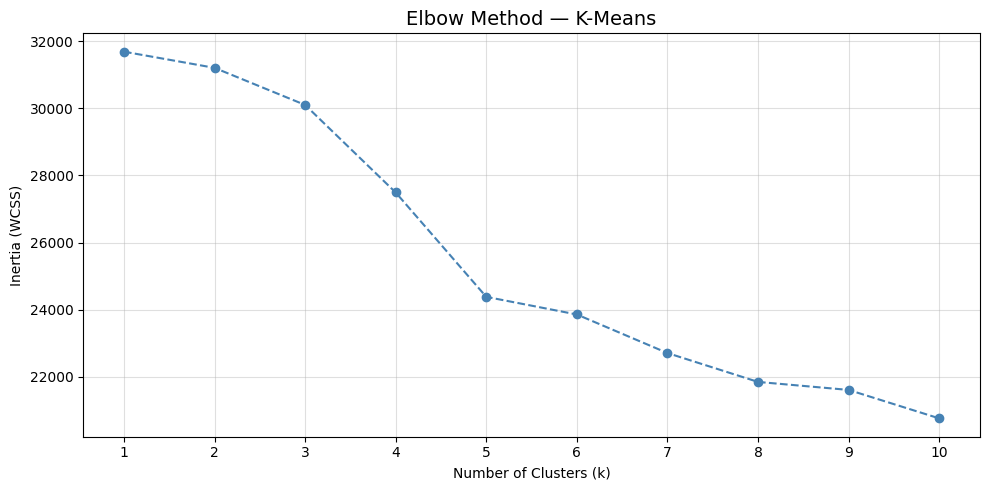

In [10]:
def elbow_plot(X, k_range=range(1, 11)):
    inertias = []
    for k in k_range:
        _, _, inertia, _ = kmeans(X, k, seed=42)
        inertias.append(inertia)

    plt.figure(figsize=(10, 5))
    plt.plot(list(k_range), inertias, marker='o', linestyle='--', color='steelblue')
    plt.title('Elbow Method — K-Means', fontsize=14)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (WCSS)')
    plt.xticks(list(k_range))
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    return inertias

inertias = elbow_plot(X_all)

In [11]:
OPTIMAL_K = 5
km_labels, km_centroids, km_inertia, km_iters = kmeans(X_all, k=OPTIMAL_K)
print(f"K-Means  |  k={OPTIMAL_K}  |  inertia={km_inertia:.4f}  |  iters={km_iters}")

K-Means  |  k=5  |  inertia=24380.4994  |  iters=7


In [12]:
# ── Cluster analysis ──────────────────────────────────────────────────────────
df_km = pd.DataFrame({'Cluster': km_labels, 'True_Label': y_all})
print("\nCluster Analysis:")
for cid in sorted(df_km['Cluster'].unique()):
    sub  = df_km[df_km['Cluster'] == cid]
    top  = sub['True_Label'].mode()[0]
    pct  = (sub['True_Label'] == top).sum() / len(sub) * 100
    name = le.inverse_transform([top])[0]
    print(f"  Cluster {cid}: dominant class = '{name}'  ({pct:.1f}% of {len(sub)} pts)")


Cluster Analysis:
  Cluster 0: dominant class = '(vertigo) Paroymsal  Positional Vertigo'  (4.3% of 2808 pts)
  Cluster 1: dominant class = 'Acne'  (100.0% of 120 pts)
  Cluster 2: dominant class = 'Hyperthyroidism'  (100.0% of 120 pts)
  Cluster 3: dominant class = 'Chicken pox'  (16.8% of 714 pts)
  Cluster 4: dominant class = 'Chronic cholestasis'  (10.4% of 1158 pts)


In [13]:
def cluster_purity(true_labels, cluster_labels):
    total = len(true_labels)
    purity = 0
    for cid in np.unique(cluster_labels):
        mask   = cluster_labels == cid
        counts = Counter(true_labels[mask])
        purity += counts.most_common(1)[0][1]
    return purity / total

purity = cluster_purity(y_all, km_labels)
sil    = silhouette_score(X_all, km_labels)
print(f"Cluster Purity     : {purity:.4f}  ({purity*100:.1f}%)")
print(f"Silhouette Score   : {sil:.4f}")

Cluster Purity     : 0.1220  (12.2%)
Silhouette Score   : 0.0666


## 5 · K-Medoids Clustering

K-Medoids is similar to K-Means but uses **actual data points** (medoids) as cluster centres,
making it more robust to outliers. The cost function is the sum of distances from each point
to its assigned medoid.



In [14]:
def compute_distance_matrix(X):
    """Full pairwise L2 distance matrix. O(n²) — use on subsampled data."""
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    return np.linalg.norm(diff, axis=2)

def kmedoids(X, k, max_iters=50, seed=42):
    np.random.seed(seed)
    n = X.shape[0]
    D = compute_distance_matrix(X)

    # Random initial medoids
    medoid_idx = np.random.choice(n, k, replace=False)

    def assign_and_cost(meds):
        dist_to_meds = D[:, meds]            # (n, k)
        lbls  = np.argmin(dist_to_meds, axis=1)
        cost  = np.sum(np.min(dist_to_meds, axis=1))
        return lbls, cost

    labels, total_cost = assign_and_cost(medoid_idx)

    for _ in range(max_iters):
        improved = False
        for m in range(k):
            for o in range(n):
                if o in medoid_idx:
                    continue
                candidate = medoid_idx.copy()
                candidate[m] = o
                _, new_cost = assign_and_cost(candidate)
                if new_cost < total_cost:
                    total_cost = new_cost
                    medoid_idx = candidate
                    improved   = True
        if not improved:
            break

    labels, total_cost = assign_and_cost(medoid_idx)
    return labels, medoid_idx, total_cost

print("K-Medoids function defined.")

K-Medoids function defined.


In [15]:
# Subsample to keep the O(n²) matrix tractable in Colab
SAMPLE_SIZE = 500
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(X_all), size=SAMPLE_SIZE, replace=False)
X_sample   = X_all[idx_sample]
y_sample   = y_all[idx_sample]

print(f"Running K-Medoids on {SAMPLE_SIZE}-sample subset ...")
kmed_labels, kmed_medoids, kmed_cost = kmedoids(X_sample, k=OPTIMAL_K)
print(f"K-Medoids  |  k={OPTIMAL_K}  |  total cost={kmed_cost:.4f}")

kmed_purity = cluster_purity(y_sample, kmed_labels)
print(f"Cluster Purity (sample): {kmed_purity:.4f}  ({kmed_purity*100:.1f}%)")

Running K-Medoids on 500-sample subset ...
K-Medoids  |  k=5  |  total cost=1205.4939
Cluster Purity (sample): 0.1780  (17.8%)


## 6 · Perceptron

The Perceptron is a **binary** linear classifier trained with the Perceptron update rule.
We frame a one-vs-rest task: *"Is this disease class 15 or not?"*



In [16]:
class Perceptron:
    """Binary Perceptron (step activation, online weight update)."""

    def __init__(self, learning_rate=0.01, n_epochs=50):
        self.learning_rate = learning_rate
        self.n_epochs      = n_epochs
        self.weights       = None
        self.bias          = None
        self.training_accuracies = []

    def _step(self, x):
        return (x > 0).astype(int)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0.0
        self.training_accuracies = []

        for epoch in range(self.n_epochs):
            for i, x_i in enumerate(X):
                z       = np.dot(x_i, self.weights) + self.bias
                y_hat   = 1 if z > 0 else 0
                error   = y[i] - y_hat
                self.weights += self.learning_rate * error * x_i
                self.bias    += self.learning_rate * error

            # Epoch-level accuracy
            preds    = self._step(X @ self.weights + self.bias)
            acc      = np.mean(preds == y)
            self.training_accuracies.append(acc)

    def predict(self, X):
        return self._step(X @ self.weights + self.bias)

Perceptron test accuracy (class 15 vs rest): 1.0000


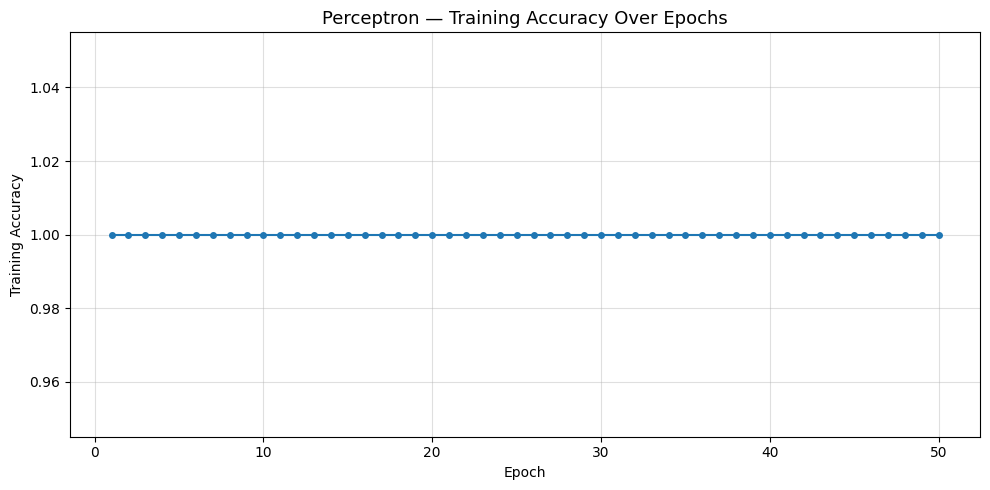

In [17]:
# One-vs-Rest: class 15 vs all others
TARGET_CLASS = 15
y_bin_train = (y_train == TARGET_CLASS).astype(int)
y_bin_test  = (y_test  == TARGET_CLASS).astype(int)

perceptron = Perceptron(learning_rate=0.01, n_epochs=50)
perceptron.fit(X_train, y_bin_train)

test_preds   = perceptron.predict(X_test)
test_acc_prc = np.mean(test_preds == y_bin_test)
print(f"Perceptron test accuracy (class {TARGET_CLASS} vs rest): {test_acc_prc:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, perceptron.n_epochs + 1), perceptron.training_accuracies, marker='o', ms=4)
plt.title('Perceptron — Training Accuracy Over Epochs', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Training Accuracy')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7 · Delta Rule — Gradient Descent

The Delta Rule uses a **linear activation** and minimises MSE via batch gradient descent.
It provides a smoother loss curve than the Perceptron and always converges on the MSE surface.

### Perceptron vs Delta Rule — key difference
| Aspect | Perceptron | Delta Rule |
|---|---|---|
| Activation | Step (binary) | Linear (continuous) |
| Update trigger | Misclassification only | Every sample, always |
| Loss | Misclassification count | MSE |
| Convergence guarantee | Only if linearly separable | Always (for linear model) |
| Output | Class label | Real-valued score |


In [19]:
class DeltaRule:
    """Widrow-Hoff Delta Rule — linear unit, batch gradient descent."""

    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.lr       = learning_rate
        self.n_epochs = n_epochs
        self.mse_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features) * 0.01
        self.bias    = np.random.randn() * 0.01
        self.mse_history = []

        for epoch in range(self.n_epochs):
            output = X @ self.weights + self.bias      # linear prediction
            error  = y - output                         # residual

            # Batch gradients
            dW = (error @ X) / n_samples
            db = error.mean()

            self.weights += self.lr * dW
            self.bias    += self.lr * db

            mse = np.mean(error ** 2)
            self.mse_history.append(mse)
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1:3d}/{self.n_epochs} | MSE: {mse:.6f}")

    def predict(self, X):
        return X @ self.weights + self.bias


  Epoch  20/100 | MSE: 0.024863
  Epoch  40/100 | MSE: 0.023799
  Epoch  60/100 | MSE: 0.022914
  Epoch  80/100 | MSE: 0.022130
  Epoch 100/100 | MSE: 0.021417


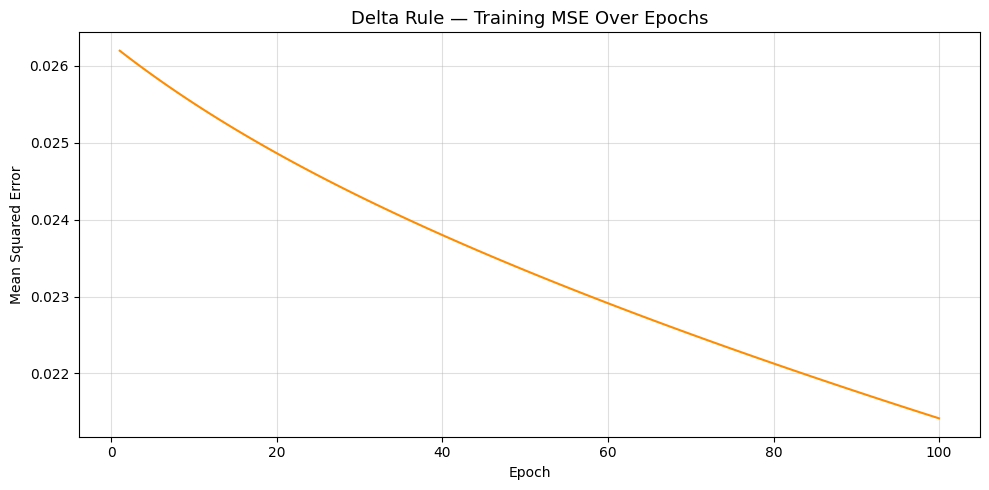

Delta Rule test accuracy (class 15 vs rest): 0.9756


In [20]:
delta_model = DeltaRule(learning_rate=0.01, n_epochs=100)
delta_model.fit(X_train, y_bin_train.astype(float))

plt.figure(figsize=(10, 5))
plt.plot(range(1, delta_model.n_epochs + 1), delta_model.mse_history, color='darkorange')
plt.title('Delta Rule — Training MSE Over Epochs', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Threshold at 0.5 for binary classification
delta_test_preds = (delta_model.predict(X_test) >= 0.5).astype(int)
delta_test_acc   = np.mean(delta_test_preds == y_bin_test)
print(f"Delta Rule test accuracy (class {TARGET_CLASS} vs rest): {delta_test_acc:.4f}")

### Convergence Comparison
- **Perceptron:** updates only on mistakes → accuracy can plateau or oscillate if not linearly separable.  
- **Delta Rule:** updates every epoch based on continuous error → MSE decreases smoothly and monotonically.


## 8 · Activation Functions


In [21]:

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1.0 - np.tanh(x) ** 2


## 9 · MLP Helper Functions

In [22]:
def to_one_hot(y, num_classes):
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

def cross_entropy_loss(y_true_oh, y_pred):
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
    return -np.sum(y_true_oh * np.log(y_pred)) / y_true_oh.shape[0]

def accuracy(y_true, y_pred_proba):
    return np.mean(np.argmax(y_pred_proba, axis=1) == y_true)

## 11 · Full MLP with Backpropagation (from scratch)

### Architecture
```
Input (n_features) → Dense(128, ReLU) → Dropout(0.3)
                   → Dense(64,  ReLU) → Dropout(0.3)
                   → Dense(32,  ReLU)
                   → Dense(n_classes, Softmax)
```


In [23]:
class MLP:
    """
    Multi-Layer Perceptron with:
      • He weight initialisation
      • ReLU hidden layers, Softmax output
      • Dropout regularisation
      • Adam optimiser
      • Mini-batch training
      • Step learning-rate decay
    """

    def __init__(self, input_size, hidden_sizes, output_size, seed=42):
        np.random.seed(seed)
        self.output_size = output_size
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        L = len(layer_sizes) - 1

        # He initialisation for ReLU layers
        self.W = [
            np.random.randn(layer_sizes[i], layer_sizes[i+1])
            * np.sqrt(2.0 / layer_sizes[i])
            for i in range(L)
        ]
        self.b = [np.zeros((1, layer_sizes[i+1])) for i in range(L)]

        # Adam moment estimates
        self.mW = [np.zeros_like(w) for w in self.W]
        self.vW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(bi) for bi in self.b]
        self.vb = [np.zeros_like(bi) for bi in self.b]
        self.adam_t = 0

        # History
        self.loss_history       = []
        self.train_acc_history  = []
        self.test_acc_history   = []

    #  Forward pass
    def forward(self, X, training=False, dropout_rate=0.3):
        self._cache = {'A0': X}
        A = X
        L = len(self.W)

        for i in range(L - 1):                     # hidden layers
            Z = A @ self.W[i] + self.b[i]
            A = relu(Z)
            if training and dropout_rate > 0:
                mask = (np.random.rand(*A.shape) > dropout_rate) / (1 - dropout_rate)
                A   *= mask
                self._cache[f'mask{i+1}'] = mask
            self._cache[f'Z{i+1}'] = Z
            self._cache[f'A{i+1}'] = A

        # Output layer (softmax)
        Z_out = A @ self.W[-1] + self.b[-1]
        A_out = softmax(Z_out)
        self._cache[f'Z{L}'] = Z_out
        self._cache[f'A{L}'] = A_out
        return A_out

    # backward pass
    def backward(self, y_oh, dropout_rate=0.3):
        n = y_oh.shape[0]
        L = len(self.W)
        gW = [None] * L
        gb = [None] * L

        # Gradient at output: softmax + cross-entropy combined
        dA = self._cache[f'A{L}'] - y_oh

        for i in reversed(range(L)):
            A_prev = self._cache[f'A{i}']
            gW[i]  = A_prev.T @ dA / n
            gb[i]  = dA.sum(axis=0, keepdims=True) / n
            if i > 0:
                dA = dA @ self.W[i].T * relu_derivative(self._cache[f'Z{i}'])
                if f'mask{i}' in self._cache:
                    dA *= self._cache[f'mask{i}']
        return gW, gb

    # Adam parameter update
    def _adam_update(self, gW, gb, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.adam_t += 1
        bc1 = 1 - beta1 ** self.adam_t
        bc2 = 1 - beta2 ** self.adam_t
        for i in range(len(self.W)):
            self.mW[i] = beta1 * self.mW[i] + (1 - beta1) * gW[i]
            self.vW[i] = beta2 * self.vW[i] + (1 - beta2) * gW[i] ** 2
            self.mb[i] = beta1 * self.mb[i] + (1 - beta1) * gb[i]
            self.vb[i] = beta2 * self.vb[i] + (1 - beta2) * gb[i] ** 2
            self.W[i] -= lr * (self.mW[i] / bc1) / (np.sqrt(self.vW[i] / bc2) + eps)
            self.b[i] -= lr * (self.mb[i] / bc1) / (np.sqrt(self.vb[i] / bc2) + eps)

    # Training loop
    def fit(self, X_tr, y_tr, X_val, y_val,
            lr=0.001, n_epochs=500, batch_size=64,
            dropout_rate=0.3, log_every=50,
            lr_decay=0.90, decay_every=100):

        current_lr = lr
        n          = X_tr.shape[0]
        y_oh       = to_one_hot(y_tr, self.output_size)

        for epoch in range(1, n_epochs + 1):
            # Step LR decay
            if epoch > 1 and (epoch - 1) % decay_every == 0:
                current_lr *= lr_decay

            # Shuffle
            perm = np.random.permutation(n)
            Xs, Ys = X_tr[perm], y_oh[perm]

            # Mini-batch updates
            for start in range(0, n, batch_size):
                Xb = Xs[start : start + batch_size]
                yb = Ys[start : start + batch_size]
                self.forward(Xb, training=True, dropout_rate=dropout_rate)
                gW, gb = self.backward(yb, dropout_rate)
                self._adam_update(gW, gb, current_lr)

            # Logging
            if epoch % log_every == 0 or epoch == 1:
                p_tr  = self.forward(X_tr,  training=False)
                p_val = self.forward(X_val, training=False)
                loss  = cross_entropy_loss(y_oh, p_tr)
                tr_a  = accuracy(y_tr,  p_tr)
                va_a  = accuracy(y_val, p_val)
                self.loss_history.append((epoch, loss))
                self.train_acc_history.append((epoch, tr_a))
                self.test_acc_history.append((epoch, va_a))
                print(f"Epoch {epoch:4d}/{n_epochs} | LR:{current_lr:.5f} | "
                      f"Loss:{loss:.4f} | Train:{tr_a:.4f} | Test:{va_a:.4f}")

    def predict(self, X):
        return np.argmax(self.forward(X, training=False), axis=1)


## 12 · Train the MLP

In [24]:
mlp = MLP(
    input_size   = X_train.shape[1],
    hidden_sizes = [128, 64, 32],
    output_size  = n_classes,
    seed         = 42
)

mlp.fit(
    X_train, y_train,
    X_test,  y_test,
    lr           = 0.001,
    n_epochs     = 500,
    batch_size   = 64,
    dropout_rate = 0.3,
    log_every    = 50,
    lr_decay     = 0.90,
    decay_every  = 100
)

Epoch    1/500 | LR:0.00100 | Loss:2.5750 | Train:0.6794 | Test:0.6789
Epoch   50/500 | LR:0.00100 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  100/500 | LR:0.00100 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  150/500 | LR:0.00090 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  200/500 | LR:0.00090 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  250/500 | LR:0.00081 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  300/500 | LR:0.00081 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  350/500 | LR:0.00073 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  400/500 | LR:0.00073 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  450/500 | LR:0.00066 | Loss:0.0000 | Train:1.0000 | Test:1.0000
Epoch  500/500 | LR:0.00066 | Loss:0.0000 | Train:1.0000 | Test:1.0000


## 13 · MLP Evaluation

In [25]:
y_pred_mlp  = mlp.predict(X_test)
final_acc   = np.mean(y_pred_mlp == y_test)

print("=" * 55)
print(f"  FINAL MLP TEST ACCURACY : {final_acc*100:.2f} %")
print("=" * 55)
print()
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

  FINAL MLP TEST ACCURACY : 100.00 %

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00

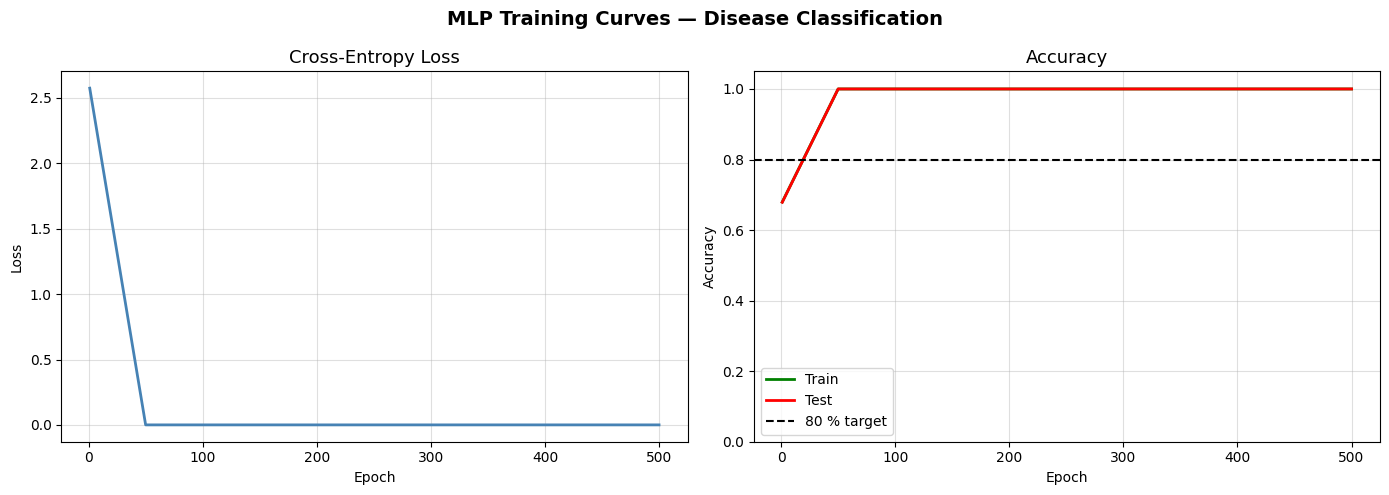

In [26]:
# Training curves
epochs_log = [x[0] for x in mlp.loss_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_log, [x[1] for x in mlp.loss_history], 'steelblue', lw=2)
axes[0].set_title('Cross-Entropy Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs_log, [x[1] for x in mlp.train_acc_history], 'g', lw=2, label='Train')
axes[1].plot(epochs_log, [x[1] for x in mlp.test_acc_history],  'r', lw=2, label='Test')
axes[1].axhline(0.80, color='k', ls='--', lw=1.5, label='80 % target')
axes[1].set_title('Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.4)
axes[1].set_ylim(0, 1.05)

plt.suptitle('MLP Training Curves — Disease Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

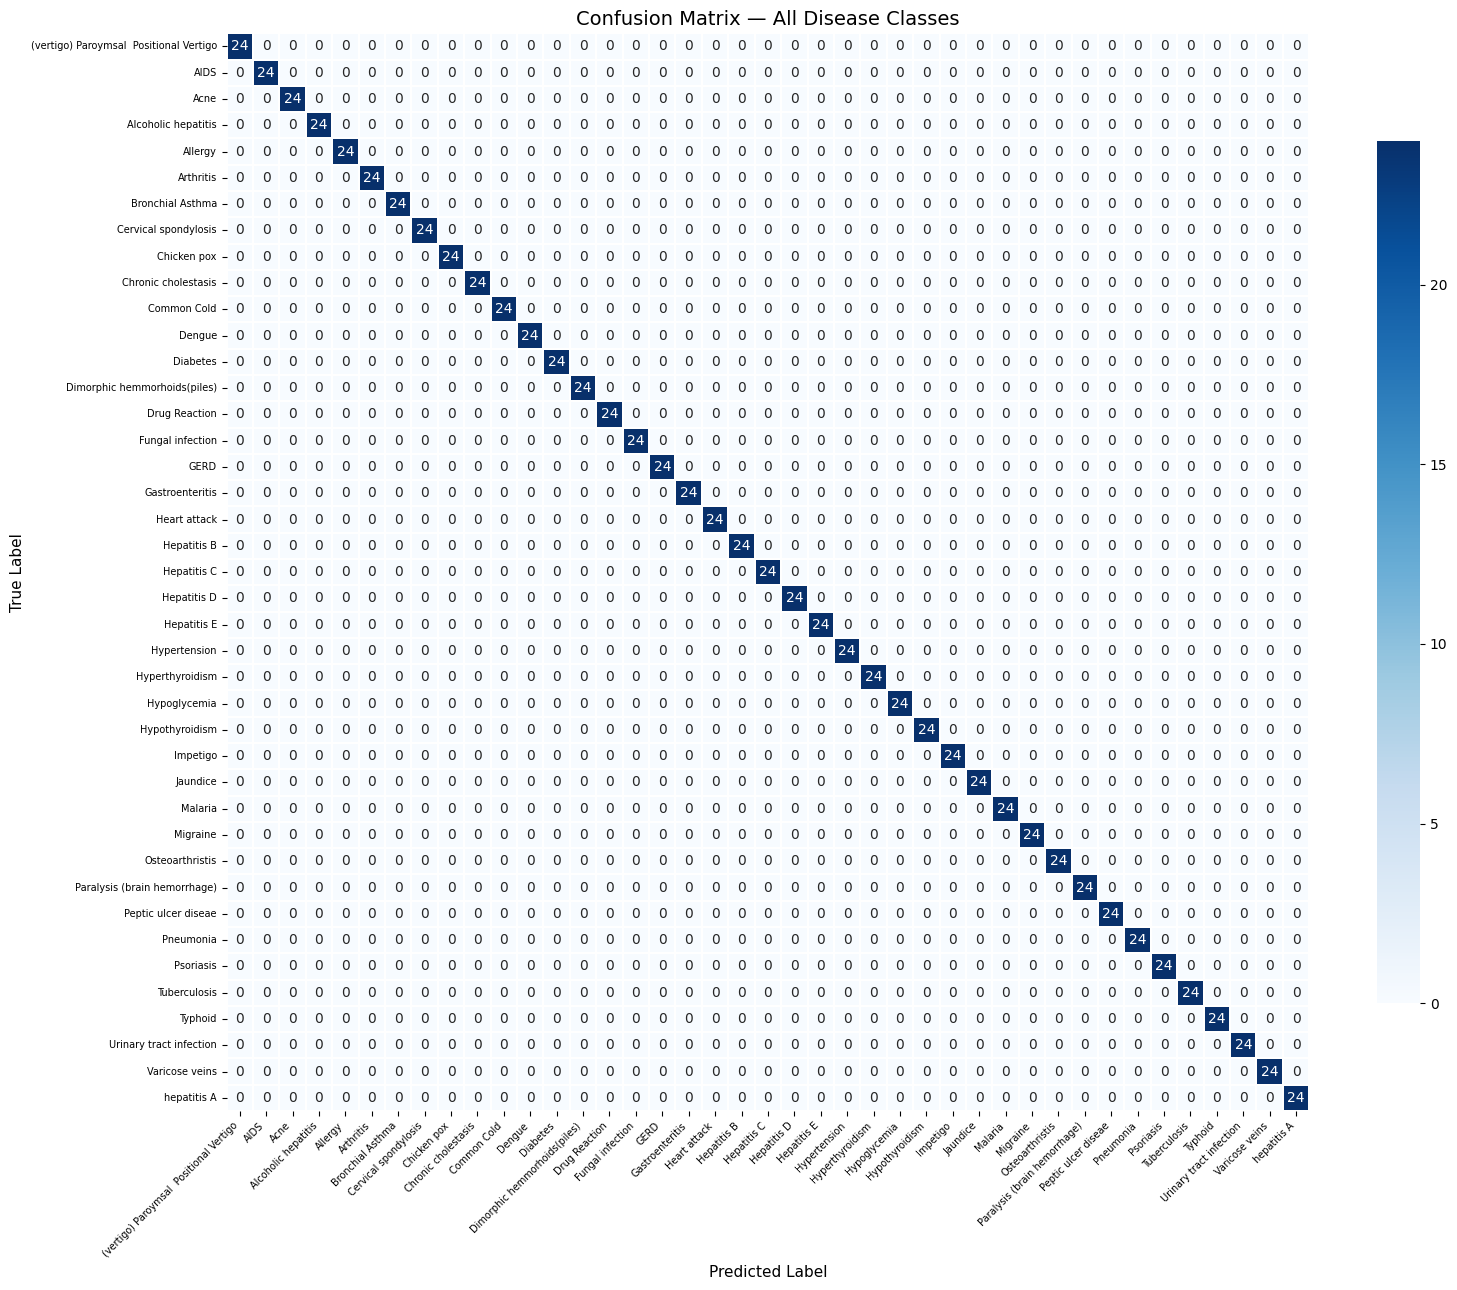

In [27]:
#  Confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Confusion Matrix — All Disease Classes', fontsize=14)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 14 · Model Comparison Summary

In [32]:
print("\n" + "="*60)
print("          FINAL MODEL COMPARISON")
print("="*60)
print(f"{'Model':<30} {'Metric':<25} {'Value':>8}")
print("-"*60)
print(f"{'K-Means (k=5)':<30} {'Cluster Purity':<25} {purity*100:>7.2f}%")
print(f"{'K-Means (k=5)':<30} {'Silhouette Score':<25} {sil:>8.4f}")
print(f"{'K-Medoids (k=5, sample)':<30} {'Cluster Purity':<25} {kmed_purity*100:>7.2f}%")
print(f"{'Perceptron (1-vs-rest)':<30} {'Test Accuracy':<25} {test_acc_prc*100:>7.2f}%")
print(f"{'Delta Rule (1-vs-rest)':<30} {'Test Accuracy':<25} {delta_test_acc*100:>7.2f}%")
print(f"{'MLP / ANN (multiclass)':<30} {'Test Accuracy':<25} {final_acc*100:>7.2f}%")
print("="*60)

# target = "TARGET MET" if final_acc >= 0.80 else " below 80%"
print(f"\n  MLP ccuracy : ", final_acc*100)


          FINAL MODEL COMPARISON
Model                          Metric                       Value
------------------------------------------------------------
K-Means (k=5)                  Cluster Purity              12.20%
K-Means (k=5)                  Silhouette Score            0.0666
K-Medoids (k=5, sample)        Cluster Purity              17.80%
Perceptron (1-vs-rest)         Test Accuracy              100.00%
Delta Rule (1-vs-rest)         Test Accuracy               97.56%
MLP / ANN (multiclass)         Test Accuracy              100.00%

  MLP ccuracy :  100.0
